## Кратко в предыдущих сериях

Что советуем освежить в памяти из курса статистики перед семинаром:

* описательные статистики (среднее, частоту абсолютную и относительную, их поиск с помощью пакета `numpy`);
* генеральную совокупность, выборку;
* случайные величины, независимость случайных величин, их распределение;
* метод Монте-Карло;
* мат. ожидание и дисперсию;
* точечные и интервальные оценки;
* оценки параметров среднего и пропорции.

# Тема 1. Интро

## 0. Цель и задачи

**Цель** — научиться не попадаться на статистические заблуждения и решать некоторые задачи с собеседований.

**Задачи:**
- вспомнить статистику (пункты выше);
- познакомиться со статистическими парадоксами;
- научиться видеть подвох в данных и не делать некорректные выводы.

## 1. Предисловие

### 1.1. Ценность этого семинара

Ценность этого семинара — показать, что аналитика — это не просто подсчёт циферок, их изображение на графиках и тривиальные выводы. Это нечто более сложное и творческое. Не всегда выводы, которые кажутся очевидно правдивыми, таковыми являются. Мы рассмотрим несколько примеров и убедимся в этом.

## 2. Статистические парадоксы

### 2.1. Парадокс Симпсона

На круговой диаграме ниже представлены проценты прохождения в Калифорнийский университет Беркли при поступлении в 1976 году. В связи с этим на университет был подан судебный иск за половую дискриминацию.

**Что мы видим?** Девушки значительно реже проходят отбор, чем юноши: 30% против 46%.


<img src="simpson paradox.png" width="600">

**Что же на самом деле происходит?** А дело всё в разной демографии на разных факультетах!

<table>
    <tr>
        <td><img src="simson paradox faculties.png" width=700></td>
        <td><img src="simpson paradox aggregate.png" width=150></td>
    </tr>
</table>

Если присмотреться, то не статистически значимо больше берут юношей только на факультеты **С**, **E** и **F**, при этом девушек больше берут на факультеты **A**, **B** и **D**. А на факультете **A** и вовсе обратная дискриминация: девушек берут больше на 20%!  Cправедливости ради, на факультет **A** проходили отбор всего 108 девушек, однако разница 20% всё равно впечатляет.

> **Вывод:** итак, парадокс Симпсона заключается в том, что мы можем видеть в каждой из групп данных определённую зависимость, но при объединении этих групп зависимость исчезает или становится противоположной. Это происходит из-за того, что зависимость заключается в каких-то других факторах. Например, в ситуации со школами дискриминации нет ни по одному из полов, а девушки реже проходят отбор, потому что чаще пытаются пройти на более сложный факультет.

**Продемонстрируем парадокс в действии:** упростим ситуацию до двух факультетов — «лёгкого» и «сложного». Пусть девушки больше стремятся пройти на сложный факультет, но при этом их чаще берут и на сложный, и на лёгкий. Подберём данные так, чтобы в итоге получилось, что по сумме девушек брали реже, чем юношей.

In [ ]:
import numpy as np
import scipy.stats as sps
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import seaborn as sns
sns.set(font_scale=1, palette='Set2')
sns.set_style('whitegrid')

In [ ]:
simpson_df = pd.DataFrame(data={
    'gender': ['male', 'female'],
    'applied_cnt_easy': [2_000, 500],
    'admitted_conversion_easy': [0.7, 0.8],
    'applied_cnt_hard': [500, 2_000],
    'admitted_conversion_hard': [0.4, 0.5],
    'applied_cnt_overall': [2_500, 2_500],
    'admitted_conversion_overall': [1_600 / 2_500, 1_400 / 2_500]
})
s = simpson_df.style

s.set_table_styles([  # create internal CSS classes
    {'selector': '.true', 'props': 'background-color: #e6ffe6;'},
    {'selector': '.false', 'props': 'background-color: #ffe6e6;'},
], overwrite=False)
cell_color = pd.DataFrame([['false', 'false', 'true'],
                           ['true', 'true', 'false']],
                          index=simpson_df.index,
                          columns=simpson_df.columns[[2, 4, 6]])
s.set_td_classes(cell_color)
s

,gender,applied_cnt_easy,admitted_conversion_easy,applied_cnt_hard,admitted_conversion_hard,applied_cnt_overall,admitted_conversion_overall
0,male,2000,0.700000,500,0.400000,2500,0.640000
1,female,500,0.800000,2000,0.500000,2500,0.560000


Визуализируем это в виде pie-диаграмм.

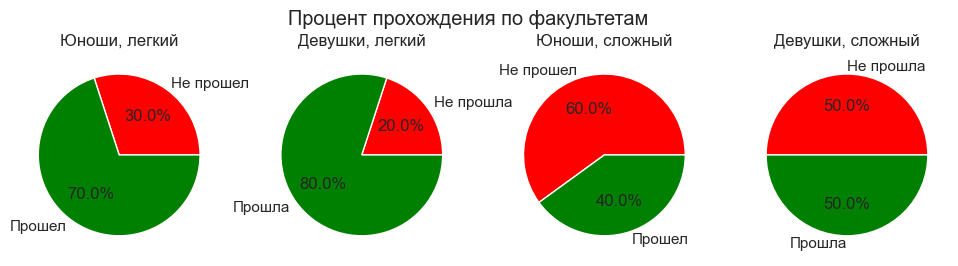

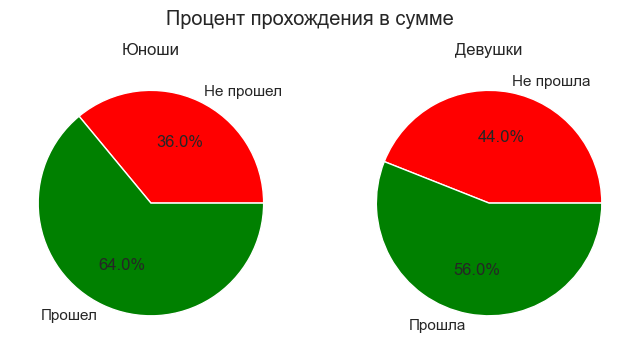

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].pie([simpson_df.loc[0, 'applied_cnt_easy'] * (1 - simpson_df.loc[0, 'admitted_conversion_easy']),
         simpson_df.loc[0, 'applied_cnt_easy'] * simpson_df.loc[0, 'admitted_conversion_easy']],
       colors = ['red', 'green'], labels=['Не прошёл', 'Прошёл'], autopct='%1.1f%%')
axes[0].set_title('Юноши, лёгкий')
axes[1].pie([simpson_df.loc[1, 'applied_cnt_easy'] * (1 - simpson_df.loc[1, 'admitted_conversion_easy']),
         simpson_df.loc[1, 'applied_cnt_easy'] * simpson_df.loc[1, 'admitted_conversion_easy']],
       colors = ['red', 'green'], labels=['Не прошла', 'Прошла'], autopct='%1.1f%%')
axes[1].set_title('Девушки, лёгкий')

axes[2].pie([simpson_df.loc[0, 'applied_cnt_hard'] * (1 - simpson_df.loc[0, 'admitted_conversion_hard']),
         simpson_df.loc[0, 'applied_cnt_hard'] * simpson_df.loc[0, 'admitted_conversion_hard']],
       colors = ['red', 'green'], labels=['Не прошёл', 'Прошёл'], autopct='%1.1f%%')
axes[2].set_title('Юноши, сложный')
axes[3].pie([simpson_df.loc[1, 'applied_cnt_hard'] * (1 - simpson_df.loc[1, 'admitted_conversion_hard']),
         simpson_df.loc[1, 'applied_cnt_hard'] * simpson_df.loc[1, 'admitted_conversion_hard']],
       colors = ['red', 'green'], labels=['Не прошла', 'Прошла'], autopct='%1.1f%%')
axes[3].set_title('Девушки, сложный')
plt.suptitle('Процент прохождения по факультетам')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].pie(
    [simpson_df.loc[0, 'applied_cnt_overall'] * (1 - simpson_df.loc[0, 'admitted_conversion_overall']),
     simpson_df.loc[0, 'applied_cnt_overall'] * simpson_df.loc[0, 'admitted_conversion_overall']],
     colors = ['red', 'green'], labels=['Не прошёл', 'Прошёл'], autopct='%1.1f%%')
axes[0].set_title('Юноши')
axes[1].pie(
    [simpson_df.loc[1, 'applied_cnt_overall'] * (1 - simpson_df.loc[1, 'admitted_conversion_overall']),
     simpson_df.loc[1, 'applied_cnt_overall'] * simpson_df.loc[1, 'admitted_conversion_overall']],
     colors = ['red', 'green'], labels=['Не прошла', 'Прошла'], autopct='%1.1f%%')
axes[1].set_title('Девушки')
plt.suptitle('Процент прохождения в сумме')
plt.show()

### 2.2. Парадокс Монти Холла

> Представь, что ты участник игры, в которой нужно выбрать одну из трёх дверей. За одной из дверей находится автомобиль, за двумя другими дверьми — козы. Ты выбираешь одну из дверей, например номер 1, затем ведущий, который знает, где находится автомобиль, а где — козы, открывает одну из оставшихся дверей, например номер 3, за которой находится коза. После этого он спрашивает тебя, не желаешь ли ты изменить свой выбор и выбрать дверь номер 2.

На первый взгляд кажется, что нет разницы, менять дверь или нет: двери осталось 2, значит, за каждой из дверей вероятность встретить автомобиль — 50%.

Мы уже знакомы с методом Монте-Карло, так давай просимулируем игру на Python! Пусть автомобиль находится за случайной дверью и игрок тоже выбирает случайную дверь. Сначала протестируем стратегию без смены двери, а потом — со сменой, сравним результаты.

In [ ]:
def monty_hall_game(change=False, n_iters=10_000):
    results = []
    doors = [1, 2, 3]
    for _ in range(n_iters):
        door_auto = np.random.choice(doors)
        door_player = np.random.choice(doors)
        doors_may_open = [door for door in doors if (door != door_auto and door != door_player)]
        door_opened = np.random.choice(doors_may_open)
        if change:
            new_door_player = [door for door in doors if (door != door_opened and door != door_player)][0]
            door_player = new_door_player


        results.append(int(door_player == door_auto))

    return results

results_change = monty_hall_game(change=True)
results_not_change = monty_hall_game(change=False)

print(f'Результат, когда меняем дверь: {np.round(100 * np.mean(results_change), 1)}%.')
print(f'Результат, когда не меняем дверь: {np.round(100 * np.mean(results_not_change), 1)}%.')

результат, когда меняем дверь: 66.2%
результат, когда не меняем дверь: 32.4%


**Поразительно!** В 2 из 3 случаев, когда мы меняем дверь, мы выигрываем, а если не меняем, то выигрываем только в 1 случае.

Но как так? Дело в том, что если не менять дверь, то ты выиграешь с вероятностью, равной первоначальной, то есть 1/3. При этом у тебя есть 2 двери и 2 варианта действий: менять дверь или нет. И где-то находится автомобиль, так как открыли дверь с козой. Значит, если вероятность выигрыша без смены двери равна 1/3, то вероятность этого события со сменой двери составляет 2/3!

Но почему 2/3? Потому что исключение одной двери перенесло всю вероятность нахождения автомобиля в ту, в которой ты можешь изменить выбор. Можно покопаться в условных вероятностях и получить требуемые 1/3 и 2/3.

### 2.3. Ошибка выжившего

> В одну американскую больницу направляли всех пострадавших в результате несчастных случаев в городе. Но больше всего в больницу попадало водителей и пассажиров, пострадавших в ДТП. Чтобы уменьшить их количество, городские власти сделали обязательным пользование ремнями безопасности. Водители и пассажиры стали пристёгиваться ремнями. После этого число ДТП осталось неизменным, но вот число пострадавших в них людей, которые поступали в больницу, даже увеличилось. Вопрос: почему?

На первый взгляд зависимость такая: начали пристёгиваться $\rightarrow$ стало больше пострадавших $\rightarrow$ ремни неэффективны.

**Но что произошло на самом деле?**

Использование ремней безопасности уменьшило число погибающих при ДТП. Многие люди, которые без ремня безопасности погибли бы и попали в морг, остались в живых, но были с травмами. Им требовалось лечение, а не вскрытие, поэтому число попадающих в больницу увеличивалось.

> Это классическая ***ошибка выжившего***. Эта ловушка мышления проявляется, когда мы смотрим только на результаты тех, кто дожил до успеха, и игнорируем невидимые неудачи. В данном случае мы не учли статистику по смертям, поэтому могли сделать неправильный вывод о полезности ремней безопасности.

### 2.4. Парадокс полицейского

#### 2.4.1. Пререквизит: условная вероятность

- ***Вероятность события $A$, если известно, что произошло событие $B$:***  
  $$\mathsf{P}(A|B) = \frac{\mathsf{P}(A \cap B)}{\mathsf{P}(B)}, \, \mathsf{P}(B) > 0.$$  
  Пример: вероятность, что выпадет 6, если известно, что выпало чётное число.  
  
  
- **Независимость событий:** события $A$ и $B$ ***независимы***, если $\mathsf{P}(A \cap B) = \mathsf{P}(A) \cdot \mathsf{P}(B)$.  
  Пример: вероятность, что выпадет 6, если известно, что в прошлый раз выпало 3.  
  
> **Замечание:** независимость ещё можно определить как $\mathsf{P}(A|B) = \mathsf{P}(A)$, если $P(B) \neq 0$.
  
- **Задачка на условные вероятности.**  

**Задача «Игральные кости»**  
Бросают две игральные кости. Известно, что сумма выпавших очков равна 8.

*Вопрос.*
- Какова вероятность того, что на первой кости выпало число 5?  

*Решение.*  

1. Пространство элементарных событий.
   Всего возможных пар исходов при броске двух костей $6 \times 6 = 36$.  

2. Условие.
   Рассматриваем только те исходы, где сумма очков равна 8:  
   $$(2, 6), (3, 5), (4, 4), (5, 3), (6, 2).$$  
   Таким образом, всего таких исходов — 5.  

3. Интересующее событие.
   На первой кости выпало 5. Подходящий исход — $(5, 3)$.  

4. Условная вероятность.
   По формуле условной вероятности:  
   $$\mathsf{P}(A|B) = \frac{\mathsf{P}(A \cap B)}{\mathsf{P}(B)}.$$  
   Вероятность события $B$ (сумма равна 8):  
   $$\mathsf{P}(B) = \frac{\text{Число подходящих исходов}}{\text{Общее число исходов}} = \frac{5}{36}.$$  
   Вероятность события $A \cap B$ (первая кость — 5, сумма — 8):  
   $$\mathsf{P}(A \cap B) = \frac{1}{36}.$$  
   Условная вероятность:  
   $$\mathsf{P}(A|B) = \frac{\mathsf{P}(A \cap B)}{\mathsf{P}(B)} = \frac{\frac{1}{36}}{\frac{5}{36}} = \frac{1}{5}.$$  

---

*Ответ.*  
Вероятность того, что на первой кости выпало число 5, если известно, что сумма равна 8, равна $\frac{1}{5}$.

---

#### 2.4.2. Пререквизит: формула Байеса и формула полной вероятности

> **Теорема** (формула Байеса): $\mathsf{P}(A|B) = \frac{\mathsf{P}(B|A)\mathsf{P}(A)}{\mathsf{P}(B)}.$

> **Доказательство:** по определению условной вероятности: $\mathsf{P}(A|B) = \frac{\mathsf{P}(A \cap B)}{\mathsf{P}(B)} = \frac{\mathsf{P}(B|A) \mathsf{P}(A)}{\mathsf{P}(B)}.$

> **Теорема** (формула полной вероятности): если $A = \sqcup A_i$, то есть $A$ состоит из объединения непересекающихся событий $A_i$, то $\mathsf{P}(B) = \sum\mathsf{P}(B|A_i)\mathsf{P}(A_i).$

> **Доказательство:** так как $A$ состоит из объединения непересекающихся событий $A_i$, то $B =  \sum\mathsf{P}(B \cap A_i)$, а каждое $\mathsf{P}(B \cap A_i) = \mathsf{P}(B|A_i)\mathsf{P}(A_i)$ по определению условной вероятности.

> **Следствие:** $\mathsf{P}(A_j|B) = \frac{\mathsf{P}(B|A_j)\mathsf{P}(A)}{\sum\mathsf{P}(B|A_i)\mathsf{P}(A_i)}.$

---
#### 2.4.3. Парадокс полицейского

> - Алкотестер почти идеален.
>     - Точность при наличии алкоголя: 100% (если человек пьян, алкотестер это определит всегда).
>     - Точность при отсутствии алкоголя: 98% (если человек не пьян, алкотестер в 2% случаев скажет, что он пьян).
> - Реально пьян только каждый тысячный человек.
> Полицейский проверил случайного человека, и алкотестер показал, что он пьян.
> Полицейский сказал, что этот человек пьян с вероятностью 98%, и взял штраф с человека.

**Вопрос:** прав ли полицейский?

**Решение:** распишем задачу с точки зрения статистики.
- Пусть $A$ — это событие «человек пьян».
- Пусть $B$ — это событие «алкотестер показал положительный результат».
- Тогда нас интересует $\mathsf{P}(A|B)$, то есть вероятность, что человек пьян при условии того, что алкотестер показал положительный результат.
- $\mathsf{P}(A) = 0.001$, так как по условию пьян каждый тысячный человек.
- $\mathsf{P}(B|A) = 1$, так как по условию алкотестер всегда показывает положительный результат, если человек пьян.
- $P\left(B|\overline{A}\right) = 0.02$, так как по условию алкотестер показывает ложноположительный результат в 2% случаев.
- Распишем $\mathsf{P}(A|B)$ по формуле Байеса:
$$\mathsf{P}(A|B) = \frac{\mathsf{P}(B|A)\mathsf{P}(A)}{\mathsf{P}(B|A)\mathsf{P}(A) + \mathsf{P}\left(B|\overline{A}\right)\mathsf{P}\left(\overline{A}\right)} = \frac{0.001}{0.001 + 0.02 \cdot 0.999} < 5\%.$$

**Итого:** если о подозреваемом ничего более неизвестно, то в таком случае положительные показания алкотестера даже близко не дают гарантии, что человек действительно пьян.

> **Вывод:** полицейский совершает ***ошибку базовой вероятности***. Он интерпретирует вероятность отрицательного результата при трезвости (98%) как вероятность опьянения при положительном результате алкотестера. Нужно уметь различать разные вероятности и правильно их интерпретировать.

### 2.5. Парадокс друзей

> Почему твои друзья популярнее, чем ты (если ты не Кайли Дженнер).

> Согласно данным учёных из университета Южной Калифорнии, более чем 98% пользователей Twitter имеют меньше друзей, чем их друзья в среднем. С чем же это связано?

Это происходит потому, что люди с большим количеством друзей чаще встречаются в социальных кругах и, следовательно, с большей вероятностью становятся друзьями других. Таким образом, при случайном выборе друга ты с большей вероятностью выберешь человека с большим числом связей, что искажает восприятие твоей собственной популярности.

Рассмотрим на небольшом примере с графом друзей.

In [ ]:
from graphviz import Graph as GVGraph
from itertools import permutations

In [ ]:
np.random.seed(seed=42)

persons = ['Алиса', 'Борис', 'Виталий', 'Геннадий', 'Елена', 'Жанна', 'Зиновий', 'Илья']
probs = dict(zip(persons, sps.beta(a=0.8, b=0.8).rvs(size=len(persons))))

relations = []
for pair in permutations(persons, 2):
    if pair[0] < pair[1]:
        friendship = sps.bernoulli((probs[pair[0]] + probs[pair[1]]) / 2).rvs()
        if friendship == 1:
            relations.append(pair)

relations

[('Алиса', 'Геннадий'),
 ('Алиса', 'Елена'),
 ('Алиса', 'Зиновий'),
 ('Алиса', 'Илья'),
 ('Борис', 'Геннадий'),
 ('Борис', 'Зиновий'),
 ('Борис', 'Илья'),
 ('Виталий', 'Геннадий'),
 ('Геннадий', 'Елена'),
 ('Геннадий', 'Жанна'),
 ('Геннадий', 'Зиновий'),
 ('Елена', 'Илья'),
 ('Жанна', 'Илья'),
 ('Зиновий', 'Илья')]

In [ ]:
class Vertex:
    def __init__(self, name):
        self.name = name
        self.neighbors = set()

    def add_neighbor(self, vertex):
        self.neighbors.add(vertex)

    def degree(self):
        return len(self.neighbors)

    def get_neighbors(self):
        return list(self.neighbors)

    def get_neighbor_by_name(self, name):
        for neighbor in self.neighbors:
            if neighbor.name == name:
                return neighbor
        return None

    def __repr__(self):
        return f"Vertex({self.name})"


class Graph:
    def __init__(self):
        self.vertices = {}

    @classmethod
    def from_edge_list(cls, edge_list):
        graph = cls()
        for from_v, to_v in edge_list:
            graph.add_edge(from_v, to_v)
        return graph

    def add_vertex(self, name):
        if name not in self.vertices:
            self.vertices[name] = Vertex(name)
        return self.vertices[name]

    def add_edge(self, from_name, to_name):
        from_vertex = self.add_vertex(from_name)
        to_vertex = self.add_vertex(to_name)
        from_vertex.add_neighbor(to_vertex)
        to_vertex.add_neighbor(from_vertex)

    def get_vertex(self, name):
        """
        Возвращает вершину по имени, либо None, если такой нет.
        """
        return self.vertices.get(name, None)

    def visualize(self):
        dot = GVGraph()
        added_edges = set()
        for vertex in self.vertices.values():
            dot.node(vertex.name)
            for neighbor in vertex.neighbors:
                edge = tuple(sorted((vertex.name, neighbor.name)))
                if edge not in added_edges:
                    dot.edge(vertex.name, neighbor.name)
                    added_edges.add(edge)
        return dot

    def __repr__(self):
        return f"Graph(vertices={list(self.vertices.keys())})"

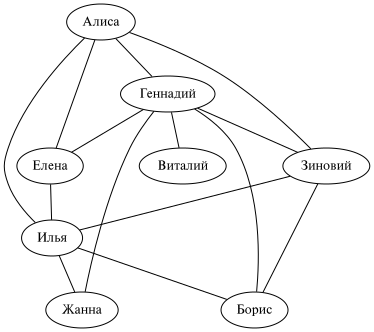

In [ ]:
friends_graph = Graph.from_edge_list(relations)
friends_graph.visualize()

In [ ]:
friends_graph.vertices

{'Алиса': Vertex(Алиса),
 'Геннадий': Vertex(Геннадий),
 'Елена': Vertex(Елена),
 'Зиновий': Vertex(Зиновий),
 'Илья': Vertex(Илья),
 'Борис': Vertex(Борис),
 'Виталий': Vertex(Виталий),
 'Жанна': Vertex(Жанна)}

In [ ]:
cnt_friends_df = pd.DataFrame(columns=['имя', 'кол-во друзей', 'среднее кол-во друзей у друзей'])

for person in persons:
    vertex_person = friends_graph.get_vertex(person)
    cnt_person = vertex_person.degree()
    neighbours = vertex_person.get_neighbors()
    cnt_friends_of_friend = []
    for neighbour in neighbours:
        cnt_friends_of_friend.append(neighbour.degree())

    avg_cnt_friends_of_friend = np.mean(cnt_friends_of_friend)
    cnt_friends_row = pd.DataFrame(data={'имя': [person],
                                         'кол-во друзей': [cnt_person],
                                         'среднее кол-во друзей у друзей': [avg_cnt_friends_of_friend]})
    cnt_friends_df = pd.concat([cnt_friends_df, cnt_friends_row], ignore_index=True)

cnt_friends_df

,имя,кол-во друзей,среднее кол-во друзей у друзей
0,Алиса,4,4.500000
1,Борис,3,5.000000
2,Виталий,1,6.000000
3,Геннадий,6,2.833333
4,Елена,3,5.000000
5,Жанна,2,5.500000
6,Зиновий,4,4.500000
7,Илья,5,3.200000


In [ ]:
cnt = len(cnt_friends_df[cnt_friends_df['кол-во друзей'] > cnt_friends_df['среднее кол-во друзей у друзей']])

print(f'У {100 * np.round(1 - cnt / len(persons), 2)}% друзей меньше, чем у среднего их друга.')

у 75.0% друзей меньше, чем у среднего их друга


Разберём пример попроще. Пусть в школе есть 2 класса: в одном — 100 человек, а во втором — 10 человек. У каждого ученика в школе спросили, сколько человек учится в его классе, а потом усреднили. Получилось: $(100 \cdot 100 + 10 \cdot 10) / (100 + 10) \approx 92$ человека, хотя на самом деле среднее число учеников в классе: $(100 + 10) / 2 = 55.$ Смещение образовалось из-за того, что чаще спрашивали тех, кто учится в большем классе (так как их просто больше).

> **Вывод:** парадокс дружбы — это пример взвешенного среднего, где вес — это число связей у человека. Люди с большим числом связей оказывают непропорционально большое влияние на статистику, поэтому смещают её в большую сторону.

**Где ещё можно встретиться с парадоксом дружбы?**
- *Парадокс ожидания поезда.* Если спросить у людей, стоящих на платформе, сколько они ждут поезд, то получится в среднем больше, чем если оценить среднее время ожидания случайного человека.
- *Нагрузки на сервер.* Если пользователи распределены неравномерно между серверами, то средний пользователь будет себя чувствовать в среднем хуже, чем средний по всем серверам.
- *Предупреждение эпидемий.* При предупреждении эпидемий обычно смотрят на здоровье не случайных людей, а друзей случайных людей. Всё потому, что друзья имеют в среднем больше контактов, а значит, лучше в первую очередь оградить их при наличии у них симптомов.

## 3. Итоги семинара

С чем выходим с занятия:
- разобрались, почему не стоит делать выводы на средних, если мы не знаем, случайно ли были собраны группы (парадокс Симпсона);
- увидели, что стоит пересчитывать вероятность событий, опираясь на новую информацию (не путать с подглядыванием: если подглянуть, то можно преждевременно открыть дверь с козой, даже не дождавшись информации от ведущего);
- разобрались, почему не стоит делать выводы на смещённой выборке (ошибка выжившего);
- увидели, что нужно глубоко понимать разные вероятности и правильно их интерпретировать;
- увидели на примере парадокс дружбы, повысили себе самооценку и поняли, как эту информацию можно использовать на практике.


## 4. Полезные материалы

- [Иллюстрация с парадоксом Симпсона](https://setosa.io/simpsons/)
- [Шортс про парадокс выжившего](https://www.youtube.com/shorts/bFg1TCLRk7s)
- [Про условную вероятность (там ещё в ссылках — формула Байеса и формула полной вероятности)](https://ru.wikipedia.org/wiki/%D0%A3%D1%81%D0%BB%D0%BE%D0%B2%D0%BD%D0%B0%D1%8F_%D0%B2%D0%B5%D1%80%D0%BE%D1%8F%D1%82%D0%BD%D0%BE%D1%81%D1%82%D1%8C)
- [Парадокс полицейского, ошибка базового процента на Википедии](https://ru.wikipedia.org/wiki/%D0%9E%D1%88%D0%B8%D0%B1%D0%BA%D0%B0_%D0%B1%D0%B0%D0%B7%D0%BE%D0%B2%D0%BE%D0%B3%D0%BE_%D0%BF%D1%80%D0%BE%D1%86%D0%B5%D0%BD%D1%82%D0%B0)
- [Статья на «Хабре» про парадокс дружбы](https://habr.com/ru/articles/383787/)
- [Статья про парадокс дружбы](https://web.archive.org/web/20141019095712/http://www-scf.usc.edu/~kooti/files/FriendParadoxRedux.pdf)